# Tutorial 3 - LUPA

The main goal of this tutorial is to demonstrate how to set up a WEC design problem with a more complex and realistic setup.
We use the [Lab Upgrade Point Absorber (LUPA)](https://pmec-osu.github.io/LUPA/) device, an open source two-body heaving point absorber under development by Oregon State University.
A deep dive video demonstration of the LUPA device and its features can be viewed [here](https://www.youtube.com/watch?v=gCcAu7H9lQI).
We will numerically replicate LUPA testing in the Large Wave Flume at the [O.H. Hinsdale Wave Research Laboratory](https://engineering.oregonstate.edu/wave-lab) in order to provide further design optimization for the WEC device concept.
This tutorial builds on the previous ones by introducing:
 
* a WEC comprised of multiple bodies
* setting up a WEC with multiple degrees of freedom (DOF) using generalized modes
* more complex PTO kinematics that depend on more than one WEC DOF 
* realistic constraints including generator maximum and continuous torque, and maximum rotational speed
* irregular waves
* mooring system dynamics

A secondary goal for this tutorial is to serve as a tool for those who are planning to run experiments with the LUPA device, to inform their experiment design.  

As with previous tutorials, this tutorial consists of two parts, with the second section building upon the first.

1. [Optimal control of a two-body WEC](#1.-Optimal-control-of-a-two-body-WEC)
2. [Control co-design of the PTO sprocket sizing for maximum electrical power](#2.-Control-co-design-of-the-PTO-sprocket-sizing-for-maximum-electrical-power)

<p><img src=https://live.staticflickr.com/65535/52793669495_72ba57da99_z.jpg alt="Digital rendering of the LUPA" width="307"> <img src=https://live.staticflickr.com/65535/52792718812_b750791167_k.jpg alt="Picture of the LUPA floating in the flume in calm water. Both bodies and mooring are visible." width="500"> <img src=https://live.staticflickr.com/65535/52793276446_9b35889ccd_k.jpg alt="Picture of the LUPA in the dry flume. Both bodies and mooring are visible. A ladder and person next to it gives context of the scale." width="500"></p>

In [1]:
import os

import gmsh, pygmsh
import capytaine as cpy
from capytaine.io.meshio import load_from_meshio
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import xarray as xr
from scipy.optimize import brute
from wavespectra.construct.frequency import pierson_moskowitz
from scipy.io import loadmat

import wecopttool as wot

## set colorblind-friendly colormap for plots
plt.style.use('tableau-colorblind10')

import logging 
logging.getLogger().setLevel(logging.INFO)

## 1. Optimal control of a two-body WEC

### WEC geometry
The creation of the `WEC` object is fundamentally identical to previous tutorials, where we use meshes of the WEC to create Capytaine `FloatingBody` objects, run BEM using Capytaine, and use the `WEC.from_bem()` method to create the `WEC` object.
The key here is that the LUPA is a two-body device (consisting of a float and a spar), which move independently in heave but in unison for all other degrees of freedom.
To model this in WecOptTool, we can create a `FloatingBody` object for each body separately with a heave DOF, combine them into a single object afterwards, and be sure the combined mass and inertia properties are properly set.

We will analyze the device in its four planar degrees of freedom:

* Heave of the buoy
* Heave of the spar
* Combined device surge
* Combined device pitch

Here we are using the generalized modes approach; an alternative solution would be to include all 3 planar DOF for each body separately and add two constraints for the pitch and surge to be equal for both bodies.

#### LUPA properties
The mass properties of the LUPA have been provided from measurements of the physical device by Oregon State University, as follows:

In [2]:
# provided by OSU
float_mass_properties = {
    'mass': 248.721,
    'CG': [0.01, 0, 0.06],
    'MOI': [66.1686, 65.3344, 17.16],
}

spar_mass_properties = {
    'mass': 175.536,
    'CG': [0, 0, -1.3],
    'MOI': [253.6344, 250.4558, 12.746],
}

water_depth = 2.7 # depth of wave flume

#### Mesh creation of the float

Here we create the mesh based on the dimensions provided by Oregon State University using `pygmsh`, available [here](https://pypi.org/project/pygmsh/).
This is the same package used by `geom.py` (click [here](https://sandialabs.github.io/WecOptTool/api_docs/wecopttool.geom.html) for API documentation) containing the predefined WaveBot and AquaHarmonics meshes used in the previous tutorials.

The float has a hole where the spar passes through it. 
In previous versions of this tutorial, the hole was larger than the spar and led to a large spike in the BEM results. 
The spike has been resolved by making the hole smaller so that the float is flush with the spar.
Like the other tutorials, a lid is added to remove any irregular frequency spikes. 

In [3]:
# mesh
mesh_size_factor = 0.3
r1 = 1.0/2  # top radius
r2 = 0.4/2  # bottom radius
h1 = 0.5  
h2 = 0.21
freeboard = 0.3
r3 = 0.05  # hole radius
with pygmsh.occ.Geometry() as geom:
    gmsh.option.setNumber('Mesh.MeshSizeFactor', mesh_size_factor)
    cyl = geom.add_cylinder([0, 0, 0], [0, 0, -h1], r1)
    cone = geom.add_cone([0, 0, -h1], [0, 0, -h2], r1, r2)
    geom.translate(cyl, [0, 0, freeboard])
    geom.translate(cone, [0, 0, freeboard]) 
    tmp = geom.boolean_union([cyl, cone])
    bar = geom.add_cylinder([0, 0, 10], [0,0,-20], r3)
    geom.boolean_difference(tmp, bar)
    mesh_float = geom.generate_mesh()

Again, we will only add the heave DOF for now.
The surge and pitch will be added after we combine the two `FloatingBody` objects.

In [4]:
# lid
mesh_obj_float = load_from_meshio(mesh_float, 'float')
lid_mesh = mesh_obj_float.generate_lid(z=-1e-2)

# floating body
float_fb = cpy.FloatingBody(mesh=mesh_obj_float, lid_mesh=lid_mesh, name="float")
#float_fb.add_translation_dof(name='Heave')

INFO:capytaine.io.meshio:Stored 3858 triangle faces as quadrilaterals
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="float"), lid_mesh=Mesh(..., name="lid for float"), dofs={}, name="float").


We can now visualize the mesh:

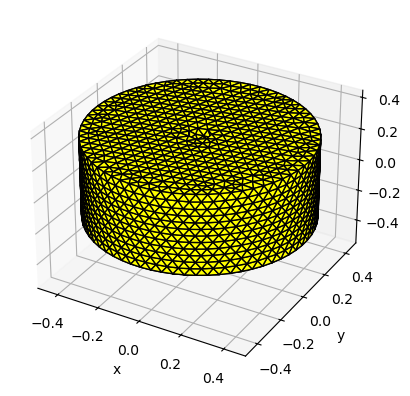

In [5]:
# show
float_fb.show_matplotlib()

# interactive, close pop-up image before being able to continue running the notebook
# float_fb.show()

#### Mesh creation of the spar

We now create the spar mesh in the same way as for the float, with the dimensions given by Oregon State University.

<p><img src=https://live.staticflickr.com/65535/52793722023_cd0b2e5d4f_k.jpg alt="spar dimensions schematic from OSU" width=700></p>

In [6]:
# mesh
mesh_size_factor = 0.1
r1 = 0.45/2  # body
r2 = 0.45  # plate
r3 = 0.10/2  # bar
h1 = 1.20  
h2 = 0.01
h3a = 3.684 - 2.05
submergence = 2.05 - h1 - h2

with pygmsh.occ.Geometry() as geom:
    gmsh.option.setNumber('Mesh.MeshSizeFactor', mesh_size_factor)
    body = geom.add_cylinder([0, 0, 0], [0, 0, -h1], r1)
    geom.translate(body, [0, 0, -submergence])
    plate = geom.add_cylinder([0, 0, 0], [0, 0, -h2], r2)
    geom.translate(plate, [0, 0, -(submergence+h1)])
    bar = geom.add_cylinder([0, 0, h3a], [0, 0, -(h3a+submergence)], r3)
    geom.boolean_union([bar, body, plate])
    mesh_spar = geom.generate_mesh()

In [7]:
# lid
mesh_obj_spar = load_from_meshio(mesh_spar, 'spar')
lid_mesh = mesh_obj_spar.generate_lid(z=-1e-2)

# floating body
spar_fb = cpy.FloatingBody(mesh=mesh_obj_spar, lid_mesh=lid_mesh, name="spar")
#spar_fb.add_translation_dof(name='Heave')

INFO:capytaine.io.meshio:Stored 6274 triangle faces as quadrilaterals
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="spar"), lid_mesh=Mesh(..., name="lid for spar"), dofs={}, name="spar").


(-0.44989582589095095, 0.4498958258909509)

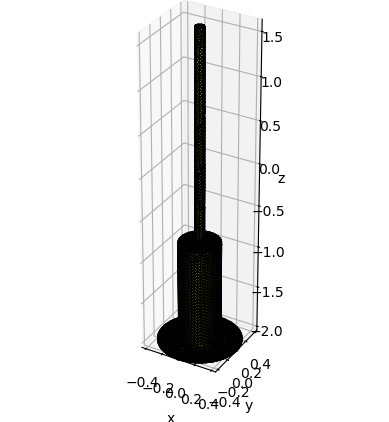

In [8]:
# show
fig = plt.figure()
xmin, xmax, ymin, ymax, zmin, zmax = spar_fb.mesh.axis_aligned_bbox
scalez = (zmax-zmin) / (xmax-xmin)
ax = fig.add_subplot(111, projection='3d')
ax.set_box_aspect(aspect=(1,1,scalez))
spar_fb.show_matplotlib(ax=ax)
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# interactive, close pop-up image before being able to continue running the notebook
# spar_fb.show()

#### Combined `FloatingBody`

With both WEC bodies defined separately, we can now define the respective centers of mass and rotation centers of the bodies.
We will then create a union of the bodies and define the properties for the overall LUPA device.
At the equilibrium position the float is neutrally buoyant while the spar is positively buoyant and requires mooring pre-tension.
The combined center of mass and moment of inertia can be found by using the given values weighted by the mass (via the parallel axis theorem for the moment of inertia).
This is also when we can specify the surge and pitch degrees of freedom.

We are using the density of *fresh* water, $\rho = 1000 kg/m^3$, since we are modeling LUPA in a wave flume.

In [9]:
# density of fresh water
rho = 1000

# mass properties float
#mass_float = float_mass_properties['mass']
cm_float = np.array(float_mass_properties['CG'])
#pitch_inertia_float = float_mass_properties['MOI'][1]
float_fb.center_of_mass = cm_float
float_fb.rotation_center = float_fb.center_of_mass

float_fb.add_all_rigid_body_dofs()
rigid_inertia_matrix_xr = xr.DataArray(data=np.asarray((np.diag([
    float_mass_properties['mass'],float_mass_properties['mass'],
    float_mass_properties['mass'],float_mass_properties['MOI'][0],
    float_mass_properties['MOI'][1],float_mass_properties['MOI'][2]]))),
                            dims=['influenced_dof', 'radiating_dof'],
                            coords={'influenced_dof': list(float_fb.dofs),
                                    'radiating_dof': list(float_fb.dofs)},
                            name="inertia_matrix")

float_fb.inertia_matrix = rigid_inertia_matrix_xr
float_fb.hydrostatic_stiffness = float_fb.immersed_part().compute_hydrostatic_stiffness()

# mass properties spar
#mass_spar = spar_mass_properties['mass']
cm_spar = np.array(spar_mass_properties['CG'])
#pitch_inertia_spar = spar_mass_properties['MOI'][1]
spar_fb.center_of_mass = cm_spar
spar_fb.rotation_center = spar_fb.center_of_mass

spar_fb.add_all_rigid_body_dofs()
rigid_inertia_matrix_xr = xr.DataArray(data=np.asarray((np.diag([
    spar_mass_properties['mass'],spar_mass_properties['mass'],
    spar_mass_properties['mass'],spar_mass_properties['MOI'][0],
    spar_mass_properties['MOI'][1],spar_mass_properties['MOI'][2]]))),
                            dims=['influenced_dof', 'radiating_dof'],
                            coords={'influenced_dof': list(spar_fb.dofs),
                                    'radiating_dof': list(spar_fb.dofs)},
                            name="inertia_matrix")

spar_fb.inertia_matrix = rigid_inertia_matrix_xr
spar_fb.hydrostatic_stiffness = spar_fb.immersed_part().compute_hydrostatic_stiffness()

# floating body
#lupa_fb = float_fb + spar_fb
lupa_fb = spar_fb + float_fb
lupa_fb.name = 'LUPA'

INFO:capytaine.bodies.bodies:The rotation dof Roll has been initialized around the point: FloatingBody(..., name="float").rotation_center = [0.01 0.   0.06]


INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="float").rotation_center = [0.01 0.   0.06]
INFO:capytaine.bodies.bodies:The rotation dof Yaw has been initialized around the point: FloatingBody(..., name="float").rotation_center = [0.01 0.   0.06]
INFO:capytaine.bodies.bodies:Clipping float with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping lid for float by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.
INFO:capytaine.bodies.bodies:The rotation dof Roll has been initialized around the point: FloatingBody(..., name="spar").rotation_center = [ 0.   0.  -1.3]
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="spar").rotation_center = [ 0.   0.  -1.3]
INFO:capytaine.bodies.bodies:The rotation dof Yaw has been initialized around the point: FloatingBody(..., name="spar").rotation_center = [ 0.   0.  -1.3]
INFO

We can now visualize the combined mesh.

(-0.4999214318270731, 0.4999248213210051)

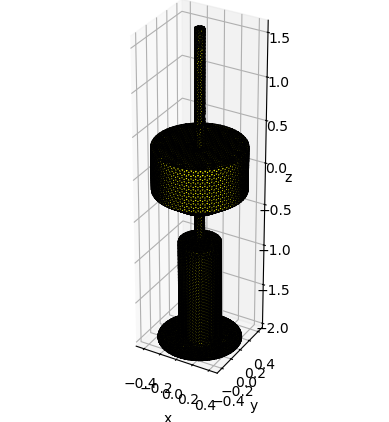

In [10]:
# show
fig = plt.figure()
xmin, xmax, ymin, ymax, zmin, zmax = lupa_fb.mesh.axis_aligned_bbox
scalez = (zmax-zmin) / (xmax-xmin)
ax = fig.add_subplot(111, projection='3d')
ax.set_box_aspect(aspect=(1,1,scalez))
lupa_fb.show_matplotlib(ax=ax)
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

#lupa_fb.show()

### Waves
Oregon State University has defined two sets of wave testing conditions for the LUPA: one corresponding to the PacWave South site and a scaling factor of 25, and one for the PacWave North site and a scaling factor of 20. 
For each site/scale they provide four wave conditions to test at the Oregon State Large Wave Flume (LWF): the maximum 90<sup>th</sup> percentile, maximum percent annual energy, maximum occurrence, and minimum 10<sup>th</sup> percentile. 

In this tutorial we will use the PacWave South conditions scaled to the LWF and will design for the maximum occurrence wave. 
The wave conditions are specified in terms of significant wave height and peak period. Waves are mostly fully developed at the PacWave site, so we will use a Pierson-Moskowitz wave spectrum. 

The irregular wave is created with multiple phase realizations.
The solver will be run once for each wave phase realization.
Each of these phase realizations leads to a slightly different result for optimal average power.
Thus, for irregular wave conditions, it is recommended to include multiple phase realizations.
The number of phase realizations required is dependent on the desired accuracy of the result, but it is generally recommended to include enough realizations for the total simulation time to equal 20 minutes.
For this tutorial, the number of realizations has been set to 2 to reduce the total runtime. 

$$ t_{total} = \frac{n_{realizations}}{f_1} $$

Because we are now using irregular waves, we need significantly more frequencies to capture the entire wave spectrum and WEC response. 

In [11]:
waves = {}

wavefreq = 0.4
f1 = wavefreq
nfreq = 10
freq = wot.frequency(f1, nfreq, False)

# regular (for testing/setup)
amplitude = 0.005
phase = 0
wavedir = 0
waves['regular'] = wot.waves.regular_wave(f1, nfreq, wavefreq, amplitude, phase, wavedir)

nrealizations = 1

### BEM
With the LUPA geometry and physical properties fully defined, we can now run Capytaine to calculate the hydrodynamic coefficients of the device, as done in previous tutorials.
Capytaine can handle generalized modes and will calculate the coefficients for our 4 degrees of freedom.
The BEM coefficients have been pre-calculated and are saved in a file.
To re-run the BEM, which takes about 1 hour, simply move or delete the existing `data/bem.nc` file.

In [12]:
# read BEM data file if it exists
filename = 'data/lupa_bem_reg.nc'
try:
    bem_data = wot.read_netcdf(filename)
except:
    bem_data = wot.run_bem(lupa_fb, freq, rho=rho, depth=water_depth)
    bem_data['radiating_dof'] = bem_data['radiating_dof'].astype(str)
    bem_data['influenced_dof'] = bem_data['influenced_dof'].astype(str)
    wot.write_netcdf(filename, bem_data)

bem_data = bem_data.fillna(0)

We now visualize the BEM results.
An irregular frequency at about 5.25 rad/s is visible in many of the plots, but this should not substantially impact our model as the wave energy at this frequency is fairly low. 

## Using Multibody for Everybody, extract the reduction matrices to go from 12 degrees of freedom to 4

In [13]:
import LUPA_M4E_inputs

# create multibody system for wavebot using M4E
m0 = [spar_mass_properties['mass'], float_mass_properties['mass']]
J0 = [spar_mass_properties['MOI'][1], float_mass_properties['MOI'][1]]

# return the reduced coordinate matrices
impedance_reduced, excitation_reduced, hydrostatic_stiffness_reduced, R0, M4E_ndof = wot.utilities.setup_from_M4E(LUPA_M4E_inputs, bem_data, [spar_fb, float_fb], m0, J0)


Table validation successful:	 No errors found.
Forces validation successful:	 No errors found.
Points validation successful:	 No errors found.


Bodies and joints table:
 Joint Connected Bodies Joint Type                        ParentCGtoJoint JointtoChildCG Prismatic Direction
     1              0 1          F                 [0, -1.30000000000000]       NaN  NaN            NaN  NaN
     2              1 2          P [0.0100000000000000, 1.36000000000000]         [0, 0]              [0, 1]

Points table:
Empty DataFrame
Columns: [Body, PointType, PointID, Rel coordinates]
Index: []

Forces table:
Empty DataFrame
Columns: [ForceType, BodiesConnected, PointType, PointID, ForceComponents, SpringParameters, DamperParameters]
Index: []

The variables that require initial conditions, in this order, are:
[X_1, Z_1, Theta_1, S_2, XD_1, ZD_1, ThetaD_1, SD_2]

Problem initialization finished in:		 0.000 seconds
All branches in the graph:
Branch 1: [1, 2]
R and RD matrices calculation finished 

INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="spar"), lid_mesh=None, dofs={}, name="spar").
INFO:capytaine.bodies.bodies:The rotation dof Roll has been initialized around the point: FloatingBody(..., name="spar").rotation_center = [ 0.   0.  -1.3]
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="spar").rotation_center = [ 0.   0.  -1.3]
INFO:capytaine.bodies.bodies:The rotation dof Yaw has been initialized around the point: FloatingBody(..., name="spar").rotation_center = [ 0.   0.  -1.3]
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="float"), lid_mesh=None, dofs={}, name="float").
INFO:capytaine.bodies.bodies:The rotation dof Roll has been initialized around the point: FloatingBody(..., name="float").rotation_center = [0.01 0.   0.06]
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="fl


[HydroAdapter] Prepared bodies:
  [1] name='spar', CoM=[ 0.   0.  -1.3]
  [2] name='float', CoM=[0.01 0.   0.06]


INFO:capytaine.bodies.bodies:Clipping float with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=CollectionOfMeshes(..., name="spar+float_mesh"), lid_mesh=None, dofs={"spar__Surge": ..., "spar__Sway": ..., "spar__Heave": ..., "spar__Roll": ..., "spar__Pitch": ..., "spar__Yaw": ..., "float__Surge": ..., "float__Sway": ..., "float__Heave": ..., "float__Roll": ..., "float__Pitch": ..., "float__Yaw": ...}, name="spar+float").


Using simplified mooring matrix that matches the mooring in WEC-Sim.

In [14]:
# add small stiffness and damping in surge and heave
stiffness_full = np.diag([1e3, 0, 1e3, 0, 0, 0])
stiffness = wot.utilities.reduce_damping_stiffness_M4E(stiffness_full, R0)

def mooring_stiffness(wec, x_wec, x_opt, wave, nsubsteps=1):
    pos = wec.vec_to_dofmat(x_wec)
    time_matrix = wec.time_mat_nsubsteps(nsubsteps)

    stiffness_var = -pos @ stiffness
    stiffness_force = jnp.dot(time_matrix,stiffness_var)
    return stiffness_force

damping_full = np.diag([1e2, 0, 1e2, 0, 0, 0])
damping = wot.utilities.reduce_damping_stiffness_M4E(damping_full, R0)

def mooring_damping(wec, x_wec, x_opt, wave, nsubsteps=1):
    pos = wec.vec_to_dofmat(x_wec)
    time_matrix = wec.time_mat_nsubsteps(nsubsteps)

    damping_var = -pos @ damping
    damping_force = jnp.dot(time_matrix,damping_var)
    return damping_force

#### Pretension of spar

The spar is positively buoyant at its equilibrium position and relies on pretension from the mooring. 
The mooring matrix above only captures the restoring forces from the mooring lines, not the pretension itself.
However, unlike Tutorial 2, we can ignore modeling this; WecOptTool assumes the device is starting in equilibrium, thus the pretension force is implied.
We modeled this in Tutorial 2 because that optimization problem (comparing the hull mass vs. pretension) required relevant constraints on the mooring/tether line, so we had to explicitly model the buoyancy, gravity, and pretension force there to make those constraints possible.
These forces have no impact on the solution to the optimization problem of interest in Part 2 of this tutorial (optimal sprocket sizing), so we can ignore them here.

### WEC object

We are now ready to create our full WEC object. 

In [15]:

# WEC
#wec = wot.WEC.from_bem(bem_data,
#                       constraints=constraints,
#                       friction=friction,
#                       f_add=f_add,
#                       dof_names=bem_data.influenced_dof.values,
#)

constraints = []
f_add = {'stiffness':mooring_stiffness, 'damping':mooring_damping}

# Define the WEC object in reduced coordinates using reduced impedance and excitation from linearization
wec = wot.WEC.from_impedance(
    waves['regular'].freq.values,
    impedance=impedance_reduced,
    exc_coeff=excitation_reduced,
    hydrostatic_stiffness=hydrostatic_stiffness_reduced, 
    constraints=constraints,
    f_add=f_add,
)

[16:30:50] WARNING  Real part of impedance for 0 has negative or close to zero terms. Shifting up elements [8] to a
                    minimum of  1e-06 N/(m/s)

[16:30:51] WARNING  Real part of impedance for 2 has negative or close to zero terms. Shifting up elements [8] to a
                    minimum of  1e-06 N/(m/s)

### Solve
We now solve the inner optimization for optimal control strategy for a fixed design.

In a formal design case, it is good practice to first test the setup with a regular wave case to confirm the WEC is responding as expected.
We have performed this step, but skip it here for the sake of brevity.
To run the regular wave, change the wave selection in the code below. 

In [16]:
# Objective function
# obj_fun = pto.average_power
obj_fun = lambda wec, x_wec, x_opt, waves : 0
nstate_opt = wec.ncomponents

# Solve
scale_x_wec = 1e1
scale_x_opt = 1e-3
scale_obj = 1e-2

results = wec.solve(
    waves['regular'], # waves['south_max_occurrence'], #
    obj_fun, 
    nstate_opt, 
    scale_x_wec=scale_x_wec,
    scale_x_opt=scale_x_opt,
    scale_obj=scale_obj,
)
power_results = [result.fun for result in results]
print(f'Optimal average electrical power: {np.mean(power_results)} W')

INFO:wecopttool.core:Solving pseudo-spectral control problem for realization number 0.
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [6.10e-02, 2.29e-03, 0.00e+00]
INFO:wecopttool.core:Optimization terminated successfully    (Exit mode 0)


Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.0
            Iterations: 1
            Function evaluations: 2
            Gradient evaluations: 1
Optimal average electrical power: 0.0 W


In [17]:
# Post-process
nsubsteps = 5
wec_fdom, wec_tdom = wec.post_process(wec, results, waves['regular'], nsubsteps)
wec_fdom_full, wec_tdom_full = wot.utilities.post_process_M4E(wec, results, waves['regular'], nsubsteps, R0)
#pto_fdom, pto_tdom = pto.post_process(wec, results, waves['regular'], nsubsteps)

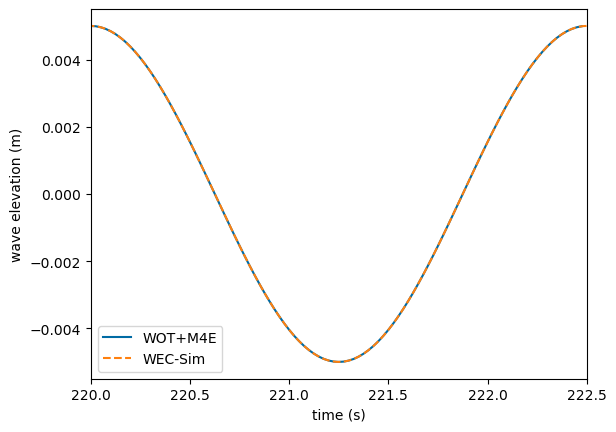

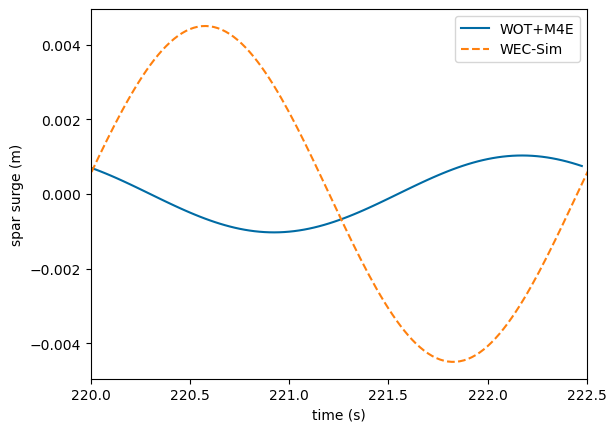

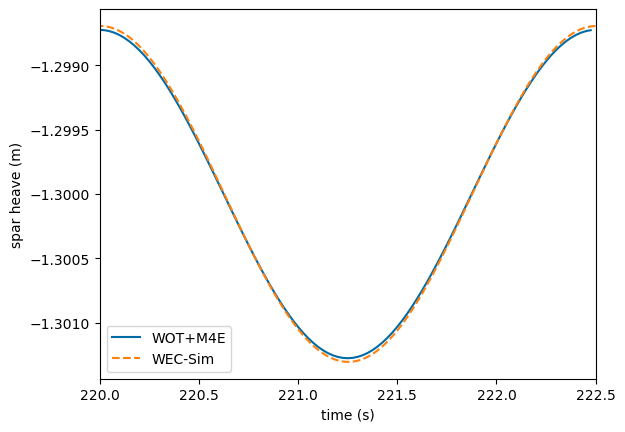

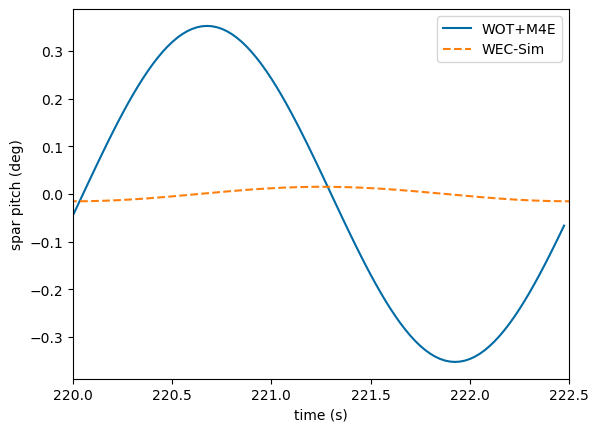

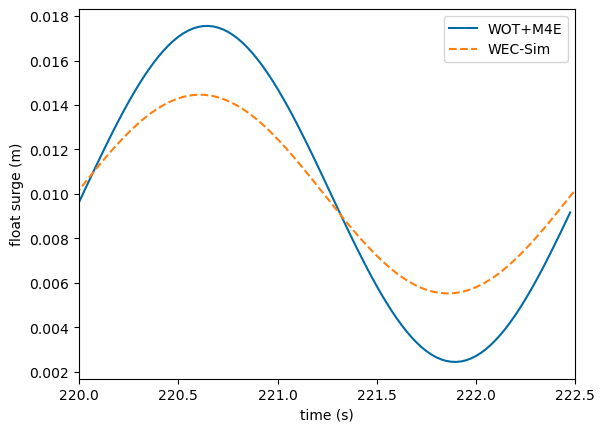

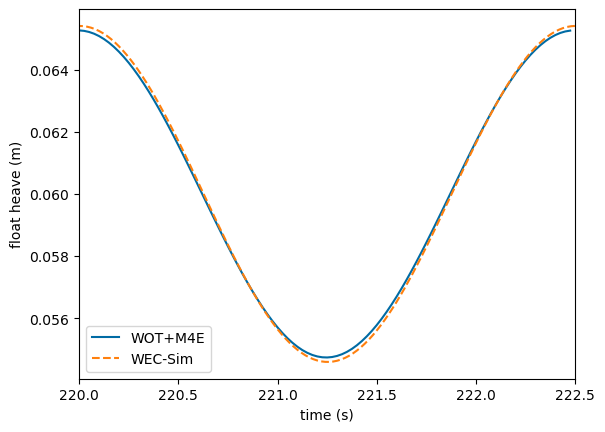

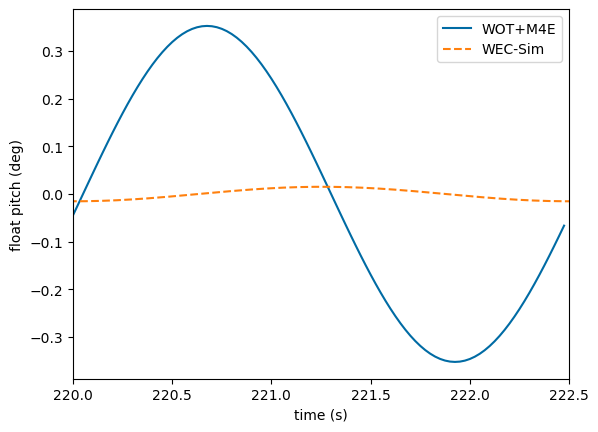

In [18]:
# Compare to WEC-Sim

ws_path = 'LUPA_WS'
ws_output = loadmat(os.path.join(ws_path,'WSoutput_01.mat'), struct_as_record=False, squeeze_me=True)

phase_offset_time = 220

plt.figure()
plt.plot(wec_tdom_full['time']+phase_offset_time, np.squeeze(wec_tdom_full.sel(realization=0)['wave_elev']), label='WOT+M4E')
plt.plot(ws_output['time'], ws_output['waveElev'], '--', label='WEC-Sim')
plt.xlabel('time (s)')
plt.ylabel('wave elevation (m)')
plt.xlim(phase_offset_time, phase_offset_time+1/wavefreq)
plt.legend()

plt.figure()
plt.plot(wec_tdom_full['time']+phase_offset_time, wec_tdom_full.sel(realization=0).pos[0,:], label='WOT+M4E')
plt.plot(ws_output['time'], ws_output['sparResponse'][:,0], '--', label='WEC-Sim')
plt.xlabel('time (s)')
plt.ylabel('spar surge (m)')
plt.xlim(phase_offset_time, phase_offset_time+1/wavefreq)
plt.legend()

plt.figure()
plt.plot(wec_tdom_full['time']+phase_offset_time, wec_tdom_full.sel(realization=0).pos[1,:]+spar_mass_properties['CG'][2], label='WOT+M4E')
plt.plot(ws_output['time'], ws_output['sparResponse'][:,2], '--', label='WEC-Sim')
plt.xlabel('time (s)')
plt.ylabel('spar heave (m)')
plt.xlim(phase_offset_time, phase_offset_time+1/wavefreq)
plt.legend()

plt.figure()
plt.plot(wec_tdom_full['time']+phase_offset_time, wec_tdom_full.sel(realization=0).pos[2,:]*180/np.pi, label='WOT+M4E')
plt.plot(ws_output['time'], ws_output['sparResponse'][:,4]*180/np.pi, '--', label='WEC-Sim')
plt.xlabel('time (s)')
plt.ylabel('spar pitch (deg)')
plt.xlim(phase_offset_time, phase_offset_time+1/wavefreq)
plt.legend()

plt.figure()
plt.plot(wec_tdom_full['time']+phase_offset_time, wec_tdom_full.sel(realization=0).pos[3,:]+float_mass_properties['CG'][0], label='WOT+M4E')
plt.plot(ws_output['time'], ws_output['floatResponse'][:,0], '--', label='WEC-Sim')
plt.xlabel('time (s)')
plt.ylabel('float surge (m)')
plt.xlim(phase_offset_time, phase_offset_time+1/wavefreq)
plt.legend()

plt.figure()
plt.plot(wec_tdom_full['time']+phase_offset_time, wec_tdom_full.sel(realization=0).pos[4,:]+float_mass_properties['CG'][2], label='WOT+M4E')
plt.plot(ws_output['time'], ws_output['floatResponse'][:,2], '--', label='WEC-Sim')
plt.xlabel('time (s)')
plt.ylabel('float heave (m)')
plt.xlim(phase_offset_time, phase_offset_time+1/wavefreq)
plt.legend()

plt.figure()
plt.plot(wec_tdom_full['time']+phase_offset_time, wec_tdom_full.sel(realization=0).pos[5,:]*180/np.pi, label='WOT+M4E')
plt.plot(ws_output['time'], ws_output['sparResponse'][:,4]*180/np.pi, '--', label='WEC-Sim')
plt.xlabel('time (s)')
plt.ylabel('float pitch (deg)')
plt.xlim(phase_offset_time, phase_offset_time+1/wavefreq)
plt.legend()


In [19]:
from multibody import MbdSystem, evaluate_trajectories
from multibody.linearization.linearization_main import LinearizationManager
from multibody.linearization.hydro_linear_mckf import HydroLinearMCKF

M4E_input_file = LUPA_M4E_inputs
fb_list = [spar_fb, float_fb]
mass_list = m0
inertia_list = J0

body_inputs = {
    i + 1: {
            'mesh': fb.mesh,
            'name': fb.name,
            'mesh_reference': 'absolute',
            'inertia_diag': [m, m, m, J, J, J],
    }
    for i, (fb, m, J) in enumerate(zip(fb_list, mass_list, inertia_list))
}

# Define the multibody system
MBDsys      = MbdSystem.from_example(M4E_input_file)
mainNumVars = M4E_input_file.ic.copy()

# Linearization
q0 = (MBDsys.ic - M4E_input_file.ic)[:len(MBDsys.Q)]

# Instantiate the linearized MBD system
LinManager = LinearizationManager(MBDsys, q0, mainNumVars, mass_list, inertia_list, print_sym_matrices=False)

# Instanciate and register hydrodynamics adapter
hydroAdapter = HydroLinearMCKF(
        MBDsys,
        (mainNumVars, mass_list, inertia_list),
        body_inputs = body_inputs,
        data = bem_data,
        equilibrium_pos=q0
        )

LinManager.register(hydroAdapter)

# Instantiate the total linearized system with attributes M,C,K,F
omega = bem_data.omega.values
FD_system = LinManager.assemble_frequency_domain(omega)


Problem initialization finished in:		 0.002 seconds
All branches in the graph:
Branch 1: [1, 2]
R and RD matrices calculation finished in:	 0.126 seconds
Symbolic EOM computation finished in:		 0.013 seconds
Compiling EOM expressions finished in:		 0.202 seconds

[Info] Updating float body 1 IC from (x=0.0, z=0.0) → (x=0.0, z=-1.3) relative to Reference_frame_Origin: (x=0, z=0) .



INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="spar"), lid_mesh=None, dofs={}, name="spar").
INFO:capytaine.bodies.bodies:The rotation dof Roll has been initialized around the point: FloatingBody(..., name="spar").rotation_center = [ 0.   0.  -1.3]
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="spar").rotation_center = [ 0.   0.  -1.3]
INFO:capytaine.bodies.bodies:The rotation dof Yaw has been initialized around the point: FloatingBody(..., name="spar").rotation_center = [ 0.   0.  -1.3]
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="float"), lid_mesh=None, dofs={}, name="float").
INFO:capytaine.bodies.bodies:The rotation dof Roll has been initialized around the point: FloatingBody(..., name="float").rotation_center = [0.01 0.   0.06]
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="fl


[HydroAdapter] Prepared bodies:
  [1] name='spar', CoM=[ 0.   0.  -1.3]
  [2] name='float', CoM=[0.01 0.   0.06]


INFO:capytaine.bodies.bodies:Clipping float with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=CollectionOfMeshes(..., name="spar+float_mesh"), lid_mesh=None, dofs={"spar__Surge": ..., "spar__Sway": ..., "spar__Heave": ..., "spar__Roll": ..., "spar__Pitch": ..., "spar__Yaw": ..., "float__Surge": ..., "float__Sway": ..., "float__Heave": ..., "float__Roll": ..., "float__Pitch": ..., "float__Yaw": ...}, name="spar+float").


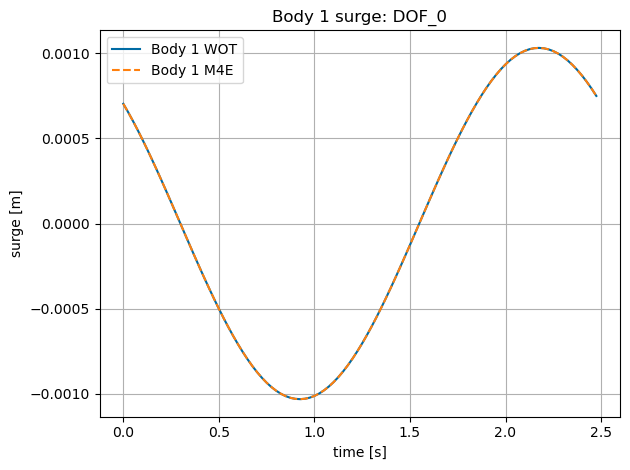

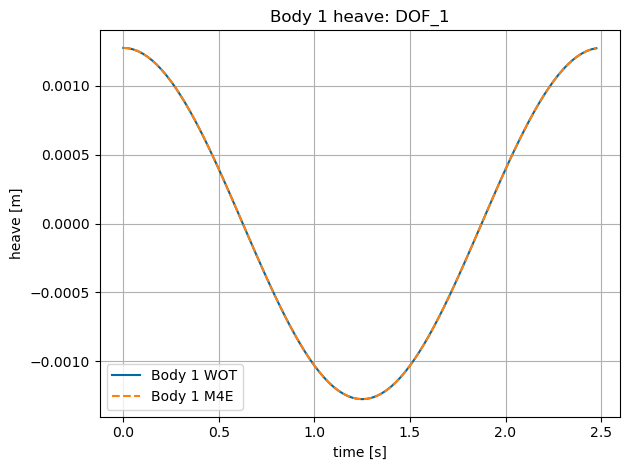

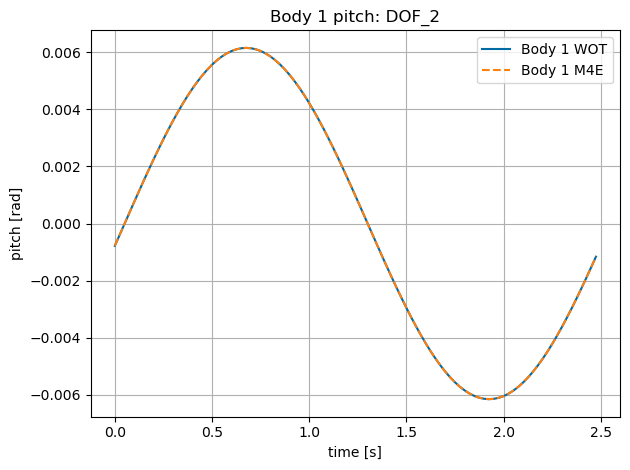

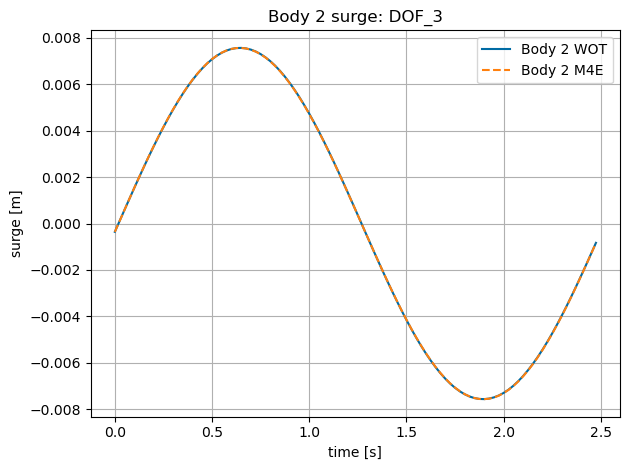

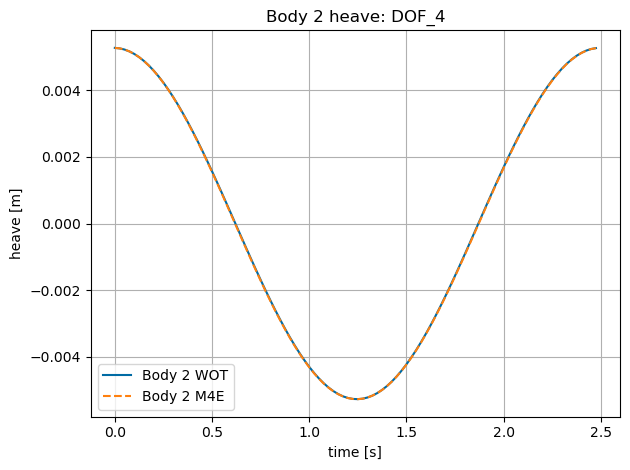

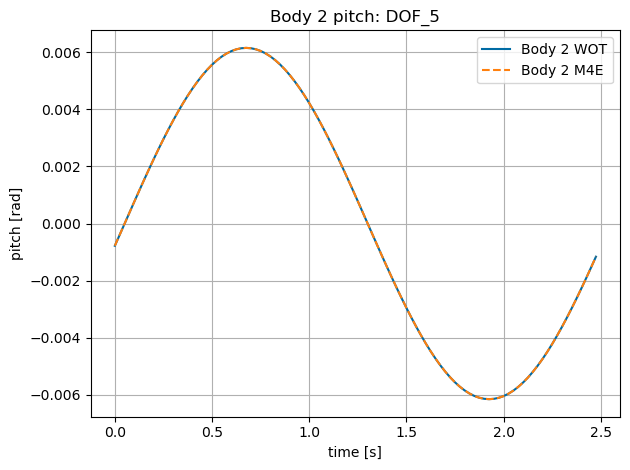

In [20]:
# Evaluate trajectories using M4E to make sure they're correct

from types import SimpleNamespace

Q = np.squeeze(wec_tdom['pos']).values
Qd = np.squeeze(wec_tdom['vel']).values
result = SimpleNamespace(t=np.squeeze(wec_tdom['time']).values, y=np.concatenate([Q, Qd], axis=0))

com_positions, com_velocities, angle_positions, _ = evaluate_trajectories(MBDsys, result, mainNumVars.copy())

# Times
t_wec = wec_tdom['time']
t_m4e = wec_tdom['time']   # or use same time if identical

# WEC-Sim / WOT positions
wec_pos = wec_tdom_full['pos'].squeeze("realization")

# Mapping: dof label, body index, component index/name
plot_map = [
    ("DOF_0", 0, "surge", com_positions[:, 0, 0], "m"),
    ("DOF_1", 0, "heave", com_positions[:, 0, 1], "m"),
    ("DOF_2", 0, "pitch", angle_positions[:, 0], "rad"),
    ("DOF_3", 1, "surge", com_positions[:, 1, 0]-float_mass_properties['CG'][0], "m"),
    ("DOF_4", 1, "heave", com_positions[:, 1, 1]+spar_mass_properties['CG'][2]-float_mass_properties['CG'][2], "m"),
    ("DOF_5", 1, "pitch", angle_positions[:, 1], "rad"),
]

for dof, body_idx, dof_name, m4e_data, units in plot_map:
    body_num = body_idx + 1

    plt.figure()
    plt.plot(
        t_wec,
        wec_pos.sel(influenced_dof=dof),
        label=f"Body {body_num} WOT"
    )
    plt.plot(
        t_m4e,
        m4e_data,
        "--",
        label=f"Body {body_num} M4E"
    )

    plt.xlabel("time [s]")
    plt.ylabel(f"{dof_name} [{units}]")
    plt.title(f"Body {body_num} {dof_name}: {dof}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

plt.show()